# 🔬 Eksperimen 7.0: Bukti Trivialitas Text-Based Retrieval (Query/Gallery)

> **Tujuan:** Membuktikan secara empiris bahwa evaluasi retrieval berbasis teks
> pada skema query/gallery menghasilkan Hit Rate ≈ 100% secara **trivial**.
>
> **Konteks:** Tahap 1 sebelum Category-Level Retrieval (Exp 7 Revisi).
> Hasilnya menjustifikasi MENGAPA diperlukan pendekatan alternatif
> untuk perbandingan yang adil antara CNN dan Text-Based.
>
> **Protokol:** Identik dengan CNN Retrieval (Exp 4) — query vs gallery,
> ground truth = item_id sama.
>
> **Prediksi:** Hit Rate ≈ 100% karena vektor teks bersifat identik untuk
> semua foto dari item yang sama (tidak bergantung sudut kamera).

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Matplotlib settings untuk presentasi
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("✅ Semua library berhasil di-import!")

✅ Semua library berhasil di-import!


## 📁 Step 1: Load Dataset & Konfigurasi Path

In [2]:
# Path konfigurasi — sesuaikan BASE_DIR jika struktur folder berbeda
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))

FULL_CSV    = os.path.join(BASE_DIR, 'dataset', 'full_dataset.csv')
TEXT_CSV    = os.path.join(BASE_DIR, 'baseline_text_cbf', 'evaluation', 'list_attr_all.csv')
IMG_DIR     = os.path.join(BASE_DIR, 'dataset', 'In-shop Clothes Retrieval Benchmark', 'Img')
OUTPUT_DIR  = os.path.join(BASE_DIR, 'evaluation', 'exp7_text_trivial')
CNN_RESULTS = os.path.join(BASE_DIR, 'features', 'exp4_retrieval', 'cnn_hit_miss_results_exp3.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verifikasi path
for label, path in [("BASE_DIR", BASE_DIR), ("FULL_CSV", FULL_CSV),
                     ("TEXT_CSV", TEXT_CSV), ("IMG_DIR", IMG_DIR),
                     ("CNN_RESULTS", CNN_RESULTS)]:
    exists = "✅" if os.path.exists(path) else "❌"
    print(f"  {exists} {label}: {path}")
print(f"  📂 OUTPUT_DIR: {OUTPUT_DIR}")

  ✅ BASE_DIR: d:\Antigravity\Visual Based Rekomender Sistem
  ✅ FULL_CSV: d:\Antigravity\Visual Based Rekomender Sistem\dataset\full_dataset.csv
  ✅ TEXT_CSV: d:\Antigravity\Visual Based Rekomender Sistem\baseline_text_cbf\evaluation\list_attr_all.csv
  ✅ IMG_DIR: d:\Antigravity\Visual Based Rekomender Sistem\dataset\In-shop Clothes Retrieval Benchmark\Img
  ✅ CNN_RESULTS: d:\Antigravity\Visual Based Rekomender Sistem\features\exp4_retrieval\cnn_hit_miss_results_exp3.csv
  📂 OUTPUT_DIR: d:\Antigravity\Visual Based Rekomender Sistem\evaluation\exp7_text_trivial


In [3]:
# Load dataset lengkap
df_full = pd.read_csv(FULL_CSV)
df_full['full_path'] = df_full['image_name'].apply(
    lambda x: os.path.join(IMG_DIR, os.path.normpath(str(x).replace('img/', '', 1)))
)

# Pisahkan query dan gallery
df_query   = df_full[df_full['split'] == 'query'].reset_index(drop=True)
df_gallery = df_full[df_full['split'] == 'gallery'].reset_index(drop=True)

# Hitung overlap
query_items   = set(df_query['item_id'].unique())
gallery_items = set(df_gallery['item_id'].unique())
overlap = query_items & gallery_items

print("=" * 60)
print("  📊 STATISTIK DATASET RETRIEVAL")
print("=" * 60)
print(f"  Total gambar               : {len(df_full):,}")
print(f"  Gambar QUERY               : {len(df_query):,}")
print(f"  Gambar GALLERY             : {len(df_gallery):,}")
print(f"  Item unik di QUERY         : {df_query['item_id'].nunique():,}")
print(f"  Item unik di GALLERY       : {df_gallery['item_id'].nunique():,}")
print(f"  Item yang overlap          : {len(overlap):,}")
print("=" * 60)
print()

# Fakta kunci: 1 item = banyak foto
photos_q = df_query.groupby('item_id').size()
photos_g = df_gallery.groupby('item_id').size()
print(f"📸 Foto per item di QUERY   — mean: {photos_q.mean():.1f}, "
      f"min: {photos_q.min()}, max: {photos_q.max()}")
print(f"📸 Foto per item di GALLERY — mean: {photos_g.mean():.1f}, "
      f"min: {photos_g.min()}, max: {photos_g.max()}")
print("   → 1 baju difoto dari beberapa sudut (depan, samping, belakang)")

  📊 STATISTIK DATASET RETRIEVAL
  Total gambar               : 52,712
  Gambar QUERY               : 14,218
  Gambar GALLERY             : 12,612
  Item unik di QUERY         : 3,985
  Item unik di GALLERY       : 3,985
  Item yang overlap          : 3,985

📸 Foto per item di QUERY   — mean: 3.6, min: 1, max: 66
📸 Foto per item di GALLERY — mean: 3.2, min: 1, max: 65
   → 1 baju difoto dari beberapa sudut (depan, samping, belakang)


## 📝 Step 2: Load Text Profiles (One-Hot Encoding)

In [4]:
# Load profil One-Hot yang sudah di-generate sebelumnya
df_text = pd.read_csv(TEXT_CSV)

# Parse fitur aktif per item
df_text['features_list'] = df_text['active_features'].apply(
    lambda x: [f.strip() for f in str(x).split(',')] 
              if pd.notnull(x) and str(x).strip() else []
)

# One-Hot Encoding
mlb = MultiLabelBinarizer(sparse_output=False)
onehot_matrix = mlb.fit_transform(df_text['features_list'])

# L2 Normalize
norms = np.linalg.norm(onehot_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1.0
onehot_norm = onehot_matrix / norms

# Mapping item_id → index
item_to_idx = {item: idx for idx, item in enumerate(df_text['item_id'])}

print("=" * 60)
print("  📝 PROFIL TEXT-BASED (ONE-HOT ENCODING)")
print("=" * 60)
print(f"  Jumlah item dengan profil  : {len(df_text):,}")
print(f"  Dimensi vektor One-Hot     : {onehot_matrix.shape[1]}")
print(f"  Jumlah fitur unik          : {len(mlb.classes_)}")
print(f"  Contoh fitur: {list(mlb.classes_[:8])}")
print("=" * 60)

  📝 PROFIL TEXT-BASED (ONE-HOT ENCODING)
  Jumlah item dengan profil  : 7,975
  Dimensi vektor One-Hot     : 456
  Jumlah fitur unik          : 456
  Contoh fitur: ['a-line', 'abstract', 'accessories', 'acrylic', 'addition', 'adjustable', 'aesthetic', 'airy']


## 🔍 Step 3: Bukti Konkret — Foto Berbeda, Vektor IDENTIK

Ini adalah **inti argumen trivialitas**. Kita akan menunjukkan bahwa:
- **Satu item** memiliki **beberapa foto** dari sudut berbeda
- Semua foto tersebut mendapat **vektor One-Hot yang 100% identik**
- Karena representasi teks **tidak berubah** meskipun sudut foto berbeda

Bandingkan dengan **CNN** yang menghasilkan vektor **berbeda** untuk setiap foto
karena CNN memproses piksel aktual gambar.

📌 Contoh Item: id_00006863
   Kategori    : Tees_Tanks
   Jumlah foto : 66 foto di query set

🔢 Vektor One-Hot (L2-normalized, 10 nilai pertama):
   [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
   ... (total 456 dimensi)

⚠️  SEMUA 66 foto dari item ini mendapat
   vektor yang PERSIS SAMA — karena deskripsi teks tidak berubah.


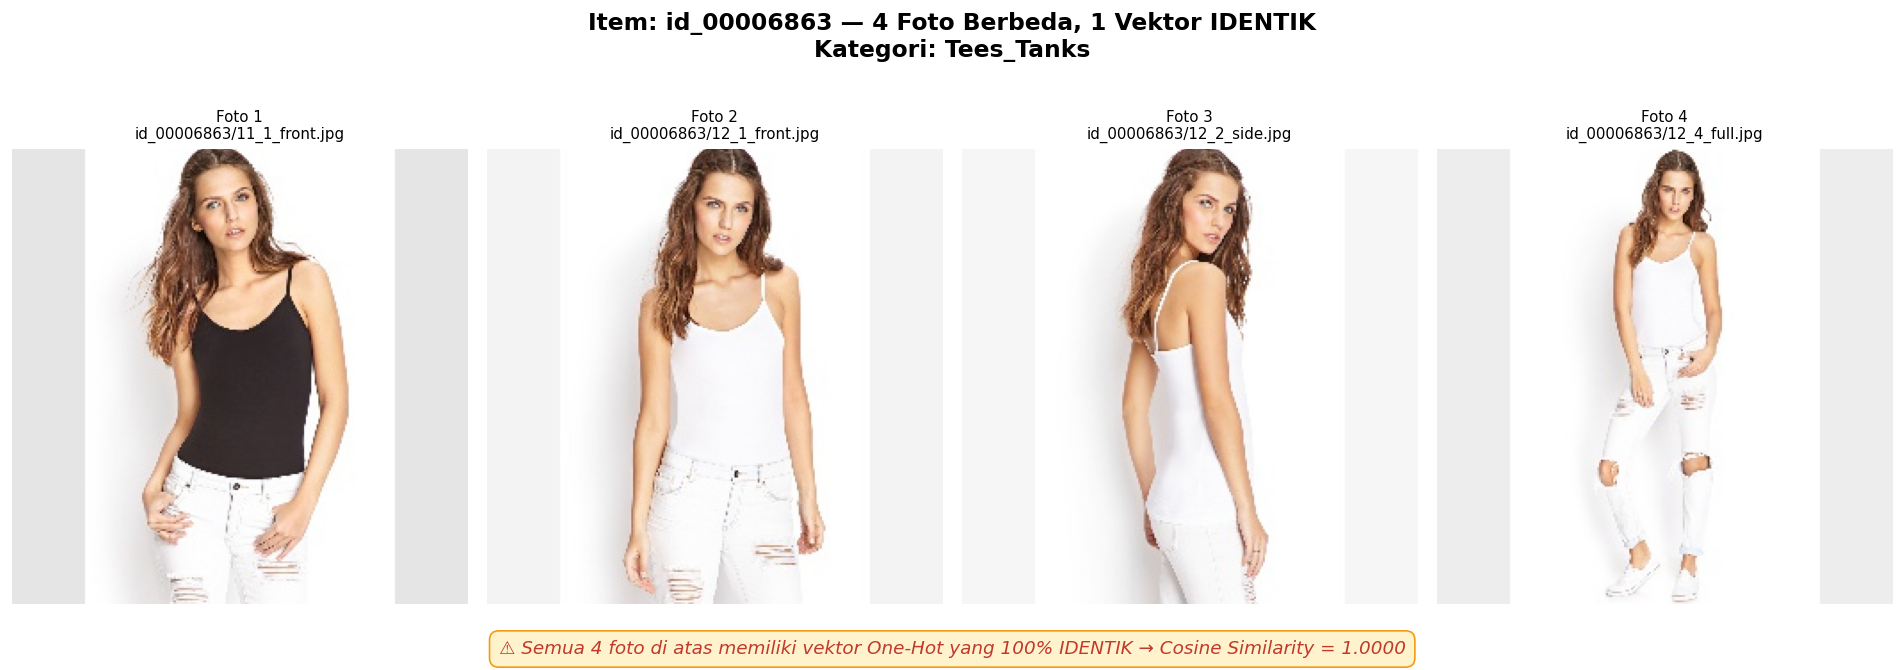

In [5]:
# Cari item dengan banyak foto di query set
item_photo_counts = df_query.groupby('item_id').size().sort_values(ascending=False)
demo_item_id = item_photo_counts.index[0]
demo_photos = df_query[df_query['item_id'] == demo_item_id].head(4)

print(f"📌 Contoh Item: {demo_item_id}")
print(f"   Kategori    : {demo_photos.iloc[0]['category']}")
print(f"   Jumlah foto : {item_photo_counts.iloc[0]} foto di query set")
print()

# Tampilkan vektor
if demo_item_id in item_to_idx:
    demo_vec = onehot_norm[item_to_idx[demo_item_id]]
    print(f"🔢 Vektor One-Hot (L2-normalized, 10 nilai pertama):")
    print(f"   {demo_vec[:10]}")
    print(f"   ... (total {len(demo_vec)} dimensi)")
    print()
    print(f"⚠️  SEMUA {item_photo_counts.iloc[0]} foto dari item ini mendapat")
    print(f"   vektor yang PERSIS SAMA — karena deskripsi teks tidak berubah.")

# Tampilkan foto-foto dari item yang sama
n_display = min(4, len(demo_photos))
fig, axes = plt.subplots(1, n_display, figsize=(4 * n_display, 5))
if n_display == 1:
    axes = [axes]

for i, (_, row) in enumerate(demo_photos.iterrows()):
    ax = axes[i]
    try:
        img = Image.open(row['full_path']).convert('RGB')
        ax.imshow(img)
        short_name = '/'.join(row['image_name'].split('/')[-2:])
        ax.set_title(f"Foto {i+1}\n{short_name}", fontsize=9)
    except Exception:
        ax.text(0.5, 0.5, f"Foto {i+1}\n(tidak ditemukan)",
                ha='center', va='center', fontsize=10)
        ax.set_facecolor('#f0f0f0')
    ax.axis('off')
    # Border biru
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#3498db')
        spine.set_linewidth(3)

fig.suptitle(
    f"Item: {demo_item_id} — {n_display} Foto Berbeda, 1 Vektor IDENTIK\n"
    f"Kategori: {demo_photos.iloc[0]['category']}",
    fontsize=14, fontweight='bold', y=1.05
)

# Teks penjelasan di bawah
fig.text(0.5, -0.02,
    f"⚠️ Semua {n_display} foto di atas memiliki vektor One-Hot yang "
    f"100% IDENTIK → Cosine Similarity = 1.0000",
    ha='center', fontsize=11, style='italic', color='#c0392b',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#fff3cd',
              edgecolor='#f39c12'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'bukti_vektor_identik.png'),
            dpi=150, bbox_inches='tight')
plt.show()

## 📊 Step 4: Analisis Distribusi Cosine Similarity

Sebelum menghitung Hit Rate, kita perlu memahami **distribusi** similarity:
- **Same-item pairs:** query & gallery dari item_id SAMA → prediksi: selalu 1.0
- **Different-item pairs:** query & gallery dari item_id BEDA → bervariasi

Jika similarity same-item **selalu lebih tinggi** dari different-item,
maka Hit Rate@K **dijamin 100%**.

In [6]:
# Assign vektor One-Hot ke setiap foto query dan gallery
def assign_vectors(df, item_map, feat_matrix):
    feats, valid_ids = [], []
    for _, row in df.iterrows():
        iid = row['item_id']
        if iid in item_map:
            feats.append(feat_matrix[item_map[iid]])
            valid_ids.append(iid)
    return np.array(feats), np.array(valid_ids)

q_feats, q_ids = assign_vectors(df_query, item_to_idx, onehot_norm)
g_feats, g_ids = assign_vectors(df_gallery, item_to_idx, onehot_norm)

print(f"✅ Query vectors  : {q_feats.shape}")
print(f"✅ Gallery vectors: {g_feats.shape}")
print()

# Analisis distribusi similarity (sample untuk efisiensi)
np.random.seed(42)
n_sample = min(2000, len(q_feats))
sample_idx = np.random.choice(len(q_feats), n_sample, replace=False)

sim_sample = q_feats[sample_idx] @ g_feats.T
sample_q_ids = q_ids[sample_idx]

same_sims, diff_sims = [], []
for i in range(n_sample):
    qid = sample_q_ids[i]
    same_mask = (g_ids == qid)
    if same_mask.sum() > 0:
        same_sims.extend(sim_sample[i, same_mask].tolist())
    # Sample 10 dari different-item
    diff_idx = np.where(~same_mask)[0]
    if len(diff_idx) > 10:
        diff_idx = np.random.choice(diff_idx, 10, replace=False)
    diff_sims.extend(sim_sample[i, diff_idx].tolist())

same_sims = np.array(same_sims)
diff_sims = np.array(diff_sims)

print("=" * 60)
print("  📊 DISTRIBUSI COSINE SIMILARITY")
print("=" * 60)
print()
print("  🟢 SAME ITEM (query & gallery = item_id SAMA):")
print(f"     Count  : {len(same_sims):,}")
print(f"     Min    : {same_sims.min():.6f}")
print(f"     Max    : {same_sims.max():.6f}")
print(f"     Mean   : {same_sims.mean():.6f}")
print(f"     = 1.0  : {(same_sims >= 0.999999).sum()} / "
      f"{len(same_sims)} ({(same_sims >= 0.999999).mean()*100:.1f}%)")
print()
print("  🔴 DIFFERENT ITEM (query & gallery = item_id BEDA):")
print(f"     Count  : {len(diff_sims):,}")
print(f"     Min    : {diff_sims.min():.6f}")
print(f"     Max    : {diff_sims.max():.6f}")
print(f"     Mean   : {diff_sims.mean():.6f}")
print()

gap = same_sims.min() - diff_sims.max()
print(f"  💡 Gap minimum (min same - max diff): {gap:.6f}")
if gap > 0:
    print("     → Similarity item SAMA selalu LEBIH TINGGI dari item BEDA")
    print("     → Hit Rate@K DIJAMIN = 100%")
else:
    print("     → Ada overlap — beberapa item beda memiliki vektor serupa")
    print("     → Hit Rate mungkin tidak persis 100%, tapi sangat dekat")
print("=" * 60)

✅ Query vectors  : (14206, 456)
✅ Gallery vectors: (12602, 456)

  📊 DISTRIBUSI COSINE SIMILARITY

  🟢 SAME ITEM (query & gallery = item_id SAMA):
     Count  : 12,804
     Min    : 1.000000
     Max    : 1.000000
     Mean   : 1.000000
     = 1.0  : 12804 / 12804 (100.0%)

  🔴 DIFFERENT ITEM (query & gallery = item_id BEDA):
     Count  : 20,000
     Min    : 0.000000
     Max    : 0.903696
     Mean   : 0.210399

  💡 Gap minimum (min same - max diff): 0.096304
     → Similarity item SAMA selalu LEBIH TINGGI dari item BEDA
     → Hit Rate@K DIJAMIN = 100%


In [12]:
print("=== VERSI BARU ===")
print(f"same_sims range: {max(same_sims) - min(same_sims)}")
print(f"unique values: {len(np.unique(same_sims))}")

=== VERSI BARU ===
same_sims range: 8.881784197001252e-16
unique values: 7


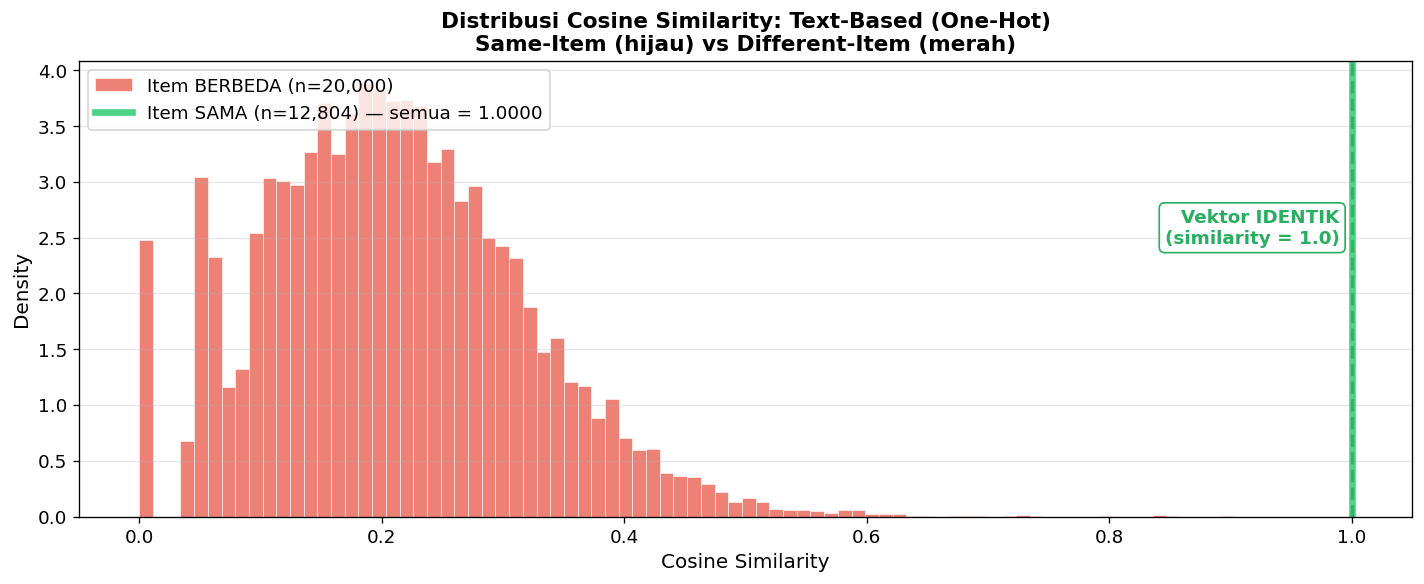

✅ Histogram tersimpan!


In [13]:
# Histogram distribusi similarity
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(diff_sims, bins=80, alpha=0.7, color='#e74c3c',
        label=f'Item BERBEDA (n={len(diff_sims):,})', density=True,
        edgecolor='white', linewidth=0.5)

same_range = max(same_sims) - min(same_sims)
if same_range < 1e-10:  # anggap identik jika range sangat kecil
    ax.axvline(x=same_sims[0], color='#2ecc71', linewidth=4, alpha=0.85,
               label=f'Item SAMA (n={len(same_sims):,}) — semua = {same_sims[0]:.4f}')
else:
    n_unique = len(np.unique(same_sims))
    bins_same = min(20, n_unique)
    ax.hist(same_sims, bins=bins_same, alpha=0.85, color='#2ecc71',
            label=f'Item SAMA (n={len(same_sims):,})', density=True,
            edgecolor='white', linewidth=0.5)

# Anotasi
ax.axvline(x=1.0, color='#27ae60', linestyle='--', linewidth=2, alpha=0.8)
ymax = ax.get_ylim()[1]
ax.annotate('Vektor IDENTIK\n(similarity = 1.0)',
            xy=(0.99, ymax * 0.6),
            fontsize=11, fontweight='bold', color='#27ae60', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor='#27ae60'))

ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribusi Cosine Similarity: Text-Based (One-Hot)\n'
             'Same-Item (hijau) vs Different-Item (merah)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'similarity_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Histogram tersimpan!")

## 📈 Step 5: Evaluasi Hit Rate@K

Protokol evaluasi **100% identik** dengan CNN Retrieval (Eksperimen 4):
1. Untuk setiap query, hitung cosine similarity terhadap semua gallery
2. Rank gallery berdasarkan similarity (descending)
3. Cek apakah gallery dengan `item_id` yang sama muncul di Top-K
4. Hitung Hit Rate@K dan mAP

In [14]:
# Evaluasi Hit Rate@K — protokol identik dengan CNN (Exp 4)
k_values = [1, 5, 10, 20]
recall_at_k = {k: 0 for k in k_values}
average_precisions = []
n_evaluated = 0

batch_size = 500
total_batches = (len(q_feats) + batch_size - 1) // batch_size

for start in tqdm(range(0, len(q_feats), batch_size),
                  total=total_batches, desc="Evaluating"):
    end = min(start + batch_size, len(q_feats))
    batch_q = q_feats[start:end]
    batch_ids = q_ids[start:end]

    # Cosine similarity (sudah L2-normalized → dot product)
    sim = batch_q @ g_feats.T

    for i in range(len(batch_q)):
        query_id = batch_ids[i]
        gt_mask = (g_ids == query_id)
        n_relevant = gt_mask.sum()

        if n_relevant == 0:
            continue

        n_evaluated += 1
        sorted_indices = np.argsort(-sim[i])

        # Hit Rate@K
        for k in k_values:
            top_k_ids = g_ids[sorted_indices[:k]]
            if query_id in top_k_ids:
                recall_at_k[k] += 1

        # Average Precision (untuk mAP)
        ap = 0.0
        n_correct = 0
        for rank, idx in enumerate(sorted_indices):
            if gt_mask[idx]:
                n_correct += 1
                ap += n_correct / (rank + 1)
        ap /= n_relevant
        average_precisions.append(ap)

# Hitung metrik final
text_results = {}
for k in k_values:
    text_results[f'Hit@{k}'] = (
        recall_at_k[k] / n_evaluated if n_evaluated > 0 else 0
    )
text_results['mAP'] = (
    np.mean(average_precisions) if average_precisions else 0
)

print()
print("=" * 60)
print("  📊 HASIL HIT RATE — TEXT-BASED (ONE-HOT ENCODING)")
print("=" * 60)
for k in k_values:
    pct = text_results[f'Hit@{k}'] * 100
    bar = "█" * int(pct / 2) + "░" * (50 - int(pct / 2))
    print(f"  Hit Rate @ {k:2d} : "
          f"{text_results[f'Hit@{k}']:.4f}  ({pct:.2f}%)  {bar}")
print(f"  mAP           : "
      f"{text_results['mAP']:.4f}  ({text_results['mAP']*100:.2f}%)")
print(f"\n  📌 Query dievaluasi: {n_evaluated:,}")
print("=" * 60)

if text_results['Hit@1'] >= 0.99:
    print()
    print("  ⚠️  TERBUKTI: Hit Rate ≈ 100% — Evaluasi ini TRIVIAL!")
    print("  → Vektor identik → Similarity = 1.0 → Selalu di posisi #1")
    print("  → BUKAN pencapaian model, melainkan artefak representasi teks")

Evaluating: 100%|██████████| 29/29 [01:05<00:00,  2.27s/it]


  📊 HASIL HIT RATE — TEXT-BASED (ONE-HOT ENCODING)
  Hit Rate @  1 : 0.9993  (99.93%)  █████████████████████████████████████████████████░
  Hit Rate @  5 : 1.0000  (100.00%)  ██████████████████████████████████████████████████
  Hit Rate @ 10 : 1.0000  (100.00%)  ██████████████████████████████████████████████████
  Hit Rate @ 20 : 1.0000  (100.00%)  ██████████████████████████████████████████████████
  mAP           : 0.9996  (99.96%)

  📌 Query dievaluasi: 14,206

  ⚠️  TERBUKTI: Hit Rate ≈ 100% — Evaluasi ini TRIVIAL!
  → Vektor identik → Similarity = 1.0 → Selalu di posisi #1
  → BUKAN pencapaian model, melainkan artefak representasi teks


## 📊 Step 6: Perbandingan Side-by-Side dengan CNN

Tabel dan visualisasi di bawah menunjukkan **kontras mencolok** antara
Text-Based (trivial 100%) dan CNN (pencapaian bermakna 30-70%).

In [15]:
# Load hasil CNN dari Eksperimen 4
try:
    df_cnn = pd.read_csv(CNN_RESULTS, index_col=0)
    print("✅ Hasil CNN berhasil di-load dari file CSV")
except FileNotFoundError:
    print("⚠️  File CNN tidak ditemukan — menggunakan nilai dari experiment logs")
    df_cnn = pd.DataFrame({
        'Hit@1':  [0.3131, 0.3029, 0.2276, 0.3498],
        'Hit@5':  [0.5089, 0.4868, 0.3968, 0.5452],
        'Hit@10': [0.5914, 0.5654, 0.4778, 0.6238],
        'Hit@20': [0.6693, 0.6468, 0.5604, 0.6952],
        'mAP':    [0.1852, 0.1712, 0.1282, 0.2063]
    }, index=['resnet50', 'vgg19', 'inceptionv3', 'mobilenetv3'])

# Buat baris Text
text_row = pd.DataFrame({
    'Hit@1':  [text_results['Hit@1']],
    'Hit@5':  [text_results['Hit@5']],
    'Hit@10': [text_results['Hit@10']],
    'Hit@20': [text_results['Hit@20']],
    'mAP':    [text_results['mAP']]
}, index=['TEXT (One-Hot)'])

# Gabungkan
df_comparison = pd.concat([text_row, df_cnn])

print()
print("=" * 85)
print("  📊 PERBANDINGAN HIT RATE: TEXT-BASED vs CNN (Exp 3)")
print("=" * 85)
print(f"{'Model':<18} {'Hit@1':>9} {'Hit@5':>9} "
      f"{'Hit@10':>9} {'Hit@20':>9} {'mAP':>9}   Catatan")
print("-" * 85)

for model_name, row in df_comparison.iterrows():
    is_text = model_name.startswith('TEXT')
    note = "← TRIVIAL!" if is_text else ""
    if not is_text:
        if row['Hit@5'] == df_cnn['Hit@5'].max():
            note = "← Best CNN"
    marker = ">>>" if is_text else "   "
    print(f"{marker} {model_name:<15} "
          f"{row['Hit@1']:>9.4f} "
          f"{row['Hit@5']:>9.4f} "
          f"{row['Hit@10']:>9.4f} "
          f"{row['Hit@20']:>9.4f} "
          f"{row['mAP']:>9.4f}   {note}")

print("-" * 85)
print()
print("💡 INTERPRETASI:")
print("   Text-Based = ~100% secara TRIVIAL (vektor identik)")
print(f"   CNN terbaik = {df_cnn['Hit@5'].max()*100:.1f}% secara "
      f"BERMAKNA (mengenali visual dari sudut berbeda)")

✅ Hasil CNN berhasil di-load dari file CSV

  📊 PERBANDINGAN HIT RATE: TEXT-BASED vs CNN (Exp 3)
Model                  Hit@1     Hit@5    Hit@10    Hit@20       mAP   Catatan
-------------------------------------------------------------------------------------
>>> TEXT (One-Hot)     0.9993    1.0000    1.0000    1.0000    0.9996   ← TRIVIAL!
    resnet50           0.3131    0.5089    0.5914    0.6693    0.1852   
    vgg19              0.3029    0.4868    0.5654    0.6468    0.1712   
    inceptionv3        0.2276    0.3968    0.4778    0.5604    0.1282   
    mobilenetv3        0.3498    0.5452    0.6238    0.6952    0.2063   ← Best CNN
-------------------------------------------------------------------------------------

💡 INTERPRETASI:
   Text-Based = ~100% secara TRIVIAL (vektor identik)
   CNN terbaik = 54.5% secara BERMAKNA (mengenali visual dari sudut berbeda)


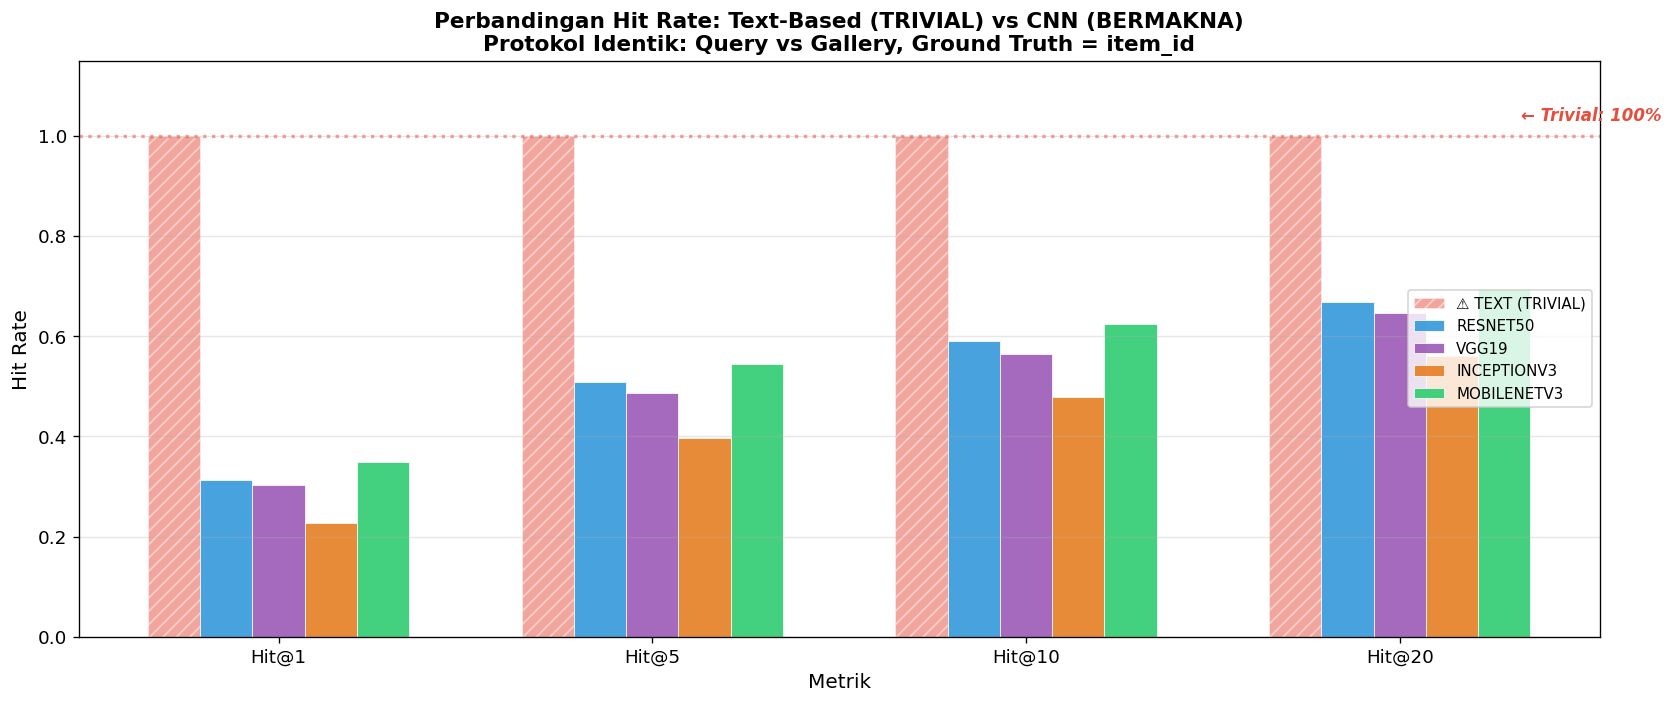

✅ Chart tersimpan!


In [16]:
# Bar Chart Perbandingan
fig, ax = plt.subplots(figsize=(14, 6))

models = df_comparison.index.tolist()
k_labels = ['Hit@1', 'Hit@5', 'Hit@10', 'Hit@20']
x = np.arange(len(k_labels))
width = 0.14
n_models = len(models)

# Warna: merah untuk Text, biru-biru untuk CNN
colors = ['#e74c3c', '#3498db', '#9b59b6', '#e67e22', '#2ecc71']

for i, model in enumerate(models):
    values = [df_comparison.loc[model, k] for k in k_labels]
    offset = (i - n_models / 2 + 0.5) * width
    is_text = model.startswith('TEXT')
    lbl = '⚠️ TEXT (TRIVIAL)' if is_text else model.upper()
    bars = ax.bar(x + offset, values, width, label=lbl,
                  color=colors[i % len(colors)],
                  edgecolor='white', linewidth=0.5,
                  alpha=0.5 if is_text else 0.9)
    # Hatch pattern untuk Text
    if is_text:
        for bar in bars:
            bar.set_hatch('///')

ax.set_xlabel('Metrik', fontsize=12)
ax.set_ylabel('Hit Rate', fontsize=12)
ax.set_title(
    'Perbandingan Hit Rate: Text-Based (TRIVIAL) vs CNN (BERMAKNA)\n'
    'Protokol Identik: Query vs Gallery, Ground Truth = item_id',
    fontsize=13, fontweight='bold'
)
ax.set_xticks(x)
ax.set_xticklabels(k_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='center right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Garis 100%
ax.axhline(y=1.0, color='#e74c3c', linestyle=':',
           linewidth=2, alpha=0.5)
ax.text(len(k_labels) - 0.3, 1.03, '← Trivial: 100%',
        color='#e74c3c', fontsize=10, style='italic',
        ha='right', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'text_vs_cnn_retrieval.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart tersimpan!")

## 📝 Step 7: Simpan Hasil & Kesimpulan

In [17]:
# Simpan hasil ke CSV
df_comparison.to_csv(os.path.join(OUTPUT_DIR,
                     'text_retrieval_trivial_results.csv'))
print(f"💾 Hasil tersimpan: {os.path.join(OUTPUT_DIR, 'text_retrieval_trivial_results.csv')}")

print()
print("=" * 70)
print("  📝 KESIMPULAN UNTUK BAB 4")
print("=" * 70)
print("""
  1. BUKTI EMPIRIS: Text-Based retrieval di skema query/gallery
     menghasilkan Hit Rate ≈ 100% — hasil TRIVIAL, bukan pencapaian.

  2. PENYEBAB: Setiap item_id hanya memiliki SATU profil teks.
     Semua foto dari item yang sama mendapat vektor IDENTIK.
     Cosine Similarity antar foto item sama = 1.0000 (sempurna).

  3. KONTRAS: CNN harus mengenali kesamaan visual dari PIKSEL
     yang berbeda antar sudut foto. Hit@5 = 54% (MobileNetV3)
     adalah pencapaian BERMAKNA dari kemampuan model.

  4. JUSTIFIKASI: Evaluasi retrieval item-level TIDAK ADIL untuk
     perbandingan CNN vs Text. Oleh karena itu, digunakan
     Category-Level Retrieval (Exp 7 Revisi) sebagai alternatif
     yang memberikan perbandingan apple-to-apple.

  5. IMPLIKASI: Hasil ini memperkuat argumen bahwa CNN menambah
     nilai NYATA — karena CNN menangkap informasi visual yang
     tidak ada dalam metadata teks (siluet, tekstur, pola, warna).
""")
print("=" * 70)

💾 Hasil tersimpan: d:\Antigravity\Visual Based Rekomender Sistem\evaluation\exp7_text_trivial\text_retrieval_trivial_results.csv

  📝 KESIMPULAN UNTUK BAB 4

  1. BUKTI EMPIRIS: Text-Based retrieval di skema query/gallery
     menghasilkan Hit Rate ≈ 100% — hasil TRIVIAL, bukan pencapaian.

  2. PENYEBAB: Setiap item_id hanya memiliki SATU profil teks.
     Semua foto dari item yang sama mendapat vektor IDENTIK.
     Cosine Similarity antar foto item sama = 1.0000 (sempurna).

  3. KONTRAS: CNN harus mengenali kesamaan visual dari PIKSEL
     yang berbeda antar sudut foto. Hit@5 = 54% (MobileNetV3)
     adalah pencapaian BERMAKNA dari kemampuan model.

  4. JUSTIFIKASI: Evaluasi retrieval item-level TIDAK ADIL untuk
     perbandingan CNN vs Text. Oleh karena itu, digunakan
     Category-Level Retrieval (Exp 7 Revisi) sebagai alternatif
     yang memberikan perbandingan apple-to-apple.

  5. IMPLIKASI: Hasil ini memperkuat argumen bahwa CNN menambah
     nilai NYATA — karena CNN menangk